In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [11]:
data = pd.read_csv('grocerydb.csv')
data.head()

,name,store,category,brand,FPro,FPro_class,price,price percal,package_weight,Protein,Total Fat,Carbohydrate,"Sugars, total","Fiber, total dietary",Sodium,Cholesterol
0,Stonyfield Organic Whole Milk Strawberry Beet ...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101
1,Stonyfield Organic Whole Milk Pear Spinach Man...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101
2,Once Upon a Farm Organic Mama Blueberry Fruit ...,Target,baby-food,Once Upon a Farm,0.583219,3.0,2.79,0.055973,90.7184,1.098901,0.549451,13.186813,7.692308,2.197802,0.010989,0.000000
3,Once Upon a Farm Organic Strawberry Kids&#39; ...,Target,baby-food,Once Upon a Farm,0.451056,0.0,2.49,0.019213,90.7184,5.494505,7.692308,15.384615,8.791209,3.296703,0.000000,0.000000
4,Horizon Organic Growing Years Strawberry Kids&...,Target,baby-food,DANNON,0.773519,3.0,4.99,0.017781,396.8930,3.030303,1.010101,14.141414,6.060606,2.020202,0.050505,0.005051


## DSC 106 Project 1 — Checkpoint EDA

**Focus:** affordability (`price`, `price percal`) vs **nutrition** (sugar, sodium, protein, etc.) and **processing** (`FPro`, NOVA `FPro_class`).

**Data quality notes (document in write-up):**
- Many rows lack `price` / `price percal` (~4k–5k each). Plots that need dollars use a subset with valid price fields.
- `price percal` is extremely right-skewed with extreme outliers → `log10` transform for visualization; optional winsorization/capping for robustness.
- Nutrition columns are **grams per 100 g** of product (per assignment).

Below: missingness, distributions, correlations, then **three static figure candidates** for the checkpoint PDF.

In [12]:
# Friendly column names (expects `data` from the load cell above)
COL_PPC = "price percal"
df = data.rename(columns={
    COL_PPC: "price_per_cal",
    "Sugars, total": "sugar_g",
    "Fiber, total dietary": "fiber_g",
    "Total Fat": "fat_g",
    "Carbohydrate": "carb_g",
})

# NOVA labels for communication
NOVA_MAP = {0.0: "0 — Unprocessed / minimal", 1.0: "1 — Culinary ingredients",
            2.0: "2 — Processed", 3.0: "3 — Ultra-processed"}
df["nova_label"] = df["FPro_class"].map(NOVA_MAP)
df["ultra_processed"] = df["FPro_class"] == 3.0

# For affordability + nutrition together: require price + key nutrients
need = ["price", "price_per_cal", "FPro", "FPro_class", "store", "sugar_g", "fiber_g", "Sodium", "Protein"]
df_core = df.dropna(subset=need).copy()
# Remove non-positive price per calorie for log transform
df_core = df_core[df_core["price_per_cal"] > 0]
df_core["log10_ppc"] = np.log10(df_core["price_per_cal"])

print(f"Raw rows: {len(df):,}")
print(f"Rows with price + price_per_cal + nutrition (analysis core): {len(df_core):,}")
df_core.head(3)

Raw rows: 26,250
Rows with price + price_per_cal + nutrition (analysis core): 20,771


,name,store,category,brand,FPro,FPro_class,price,price_per_cal,package_weight,Protein,fat_g,carb_g,sugar_g,fiber_g,Sodium,Cholesterol,nova_label,ultra_processed,log10_ppc
0,Stonyfield Organic Whole Milk Strawberry Beet ...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101,3 — Ultra-processed,True,-1.356704
1,Stonyfield Organic Whole Milk Pear Spinach Man...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101,3 — Ultra-processed,True,-1.356704
2,Once Upon a Farm Organic Mama Blueberry Fruit ...,Target,baby-food,Once Upon a Farm,0.583219,3.0,2.79,0.055973,90.7184,1.098901,0.549451,13.186813,7.692308,2.197802,0.010989,0.000000,3 — Ultra-processed,True,-1.252020


In [13]:
# Missingness overview (full raw table)
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({"missing": miss, "pct": miss_pct})
display(miss_df[miss_df["missing"] > 0])

# Quick sanity: stores and NOVA mix in core subset
display(df_core["store"].value_counts())
display(df_core["FPro_class"].value_counts().sort_index())

,missing,pct
price_per_cal,5470,20.8
price,4030,15.4
package_weight,1275,4.9
brand,69,0.3
fiber_g,9,0.0
sugar_g,9,0.0


store
Walmart       7380
WholeFoods    7046
Target        6345
Name: count, dtype: int64

FPro_class
0.0     2370
1.0      414
2.0     1906
3.0    16081
Name: count, dtype: int64

price_per_cal 1% / 99%: 0.000617 — 0.149750 (max raw 15.0716)


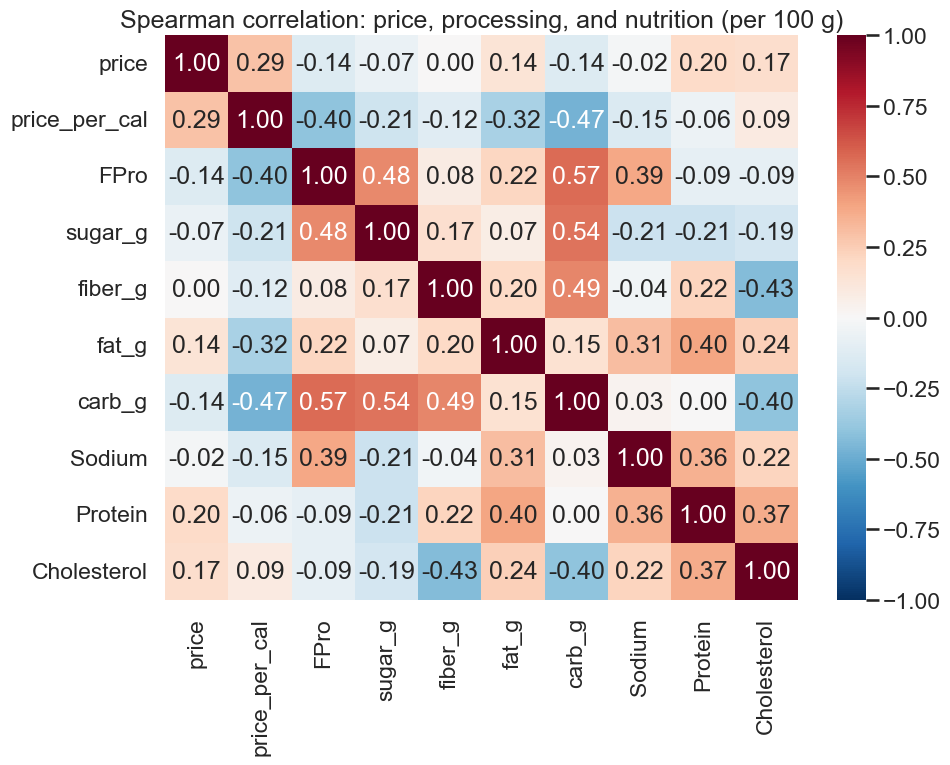

In [14]:
# Outliers: price_per_cal (very long right tail)
ppc = df_core["price_per_cal"]
q01, q99 = ppc.quantile([0.01, 0.99])
print(f"price_per_cal 1% / 99%: {q01:.6f} — {q99:.6f} (max raw {ppc.max():.4f})")

# Optional: cap for *display* only (keep df_core intact for transparency; use df_plot for heavy tails)
df_plot = df_core.copy()
df_plot["ppc_capped"] = df_plot["price_per_cal"].clip(upper=q99)
df_plot["log10_ppc_cap"] = np.log10(df_plot["ppc_capped"])

# Key correlations on core subset (Spearman handles skew / monotonic relationships)
num_cols = ["price", "price_per_cal", "FPro", "sugar_g", "fiber_g", "fat_g", "carb_g", "Sodium", "Protein", "Cholesterol"]
corr_s = df_core[num_cols].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation: price, processing, and nutrition (per 100 g)")
plt.tight_layout()
plt.show()

In [15]:
# Store-level medians (nutrition + affordability) — useful for narrative
summ = df_core.groupby("store").agg(
    n=("name", "count"),
    med_ppc=("price_per_cal", "median"),
    med_log_ppc=("log10_ppc", "median"),
    med_FPro=("FPro", "median"),
    pct_ultra=("ultra_processed", "mean"),
    med_sugar=("sugar_g", "median"),
    med_sodium=("Sodium", "median"),
    med_protein=("Protein", "median"),
    med_fiber=("fiber_g", "median"),
).round(4)
summ["pct_ultra"] = (summ["pct_ultra"] * 100).round(1)
summ

,n,med_ppc,med_log_ppc,med_FPro,pct_ultra,med_sugar,med_sodium,med_protein,med_fiber
store,,,,,,,,,
Target,6345,0.0057,-2.2442,0.8626,84.6,5.2083,0.3750,7.7519,2.0833
Walmart,7380,0.0034,-2.4649,0.8210,81.2,3.8462,0.3529,6.1856,1.1765
WholeFoods,7046,0.0093,-2.0337,0.7209,67.0,3.5714,0.1901,6.2500,1.8182


### Checkpoint figure A — Affordability vs processing, by retailer

**Takeaway angle:** Distribution of **price per calorie** (log scale) differs by **store**; split by **ultra-processed vs not** to connect affordability to NOVA-style processing.

**Encodings:** x = store, y = log10(price per calorie), split violin hue = ultra-processed flag.

/var/folders/5p/vrbc0kc57yd4shnbpk0r_0rw0000gn/T/ipykernel_75949/977765449.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Walmart", "Target", "Whole Foods"])


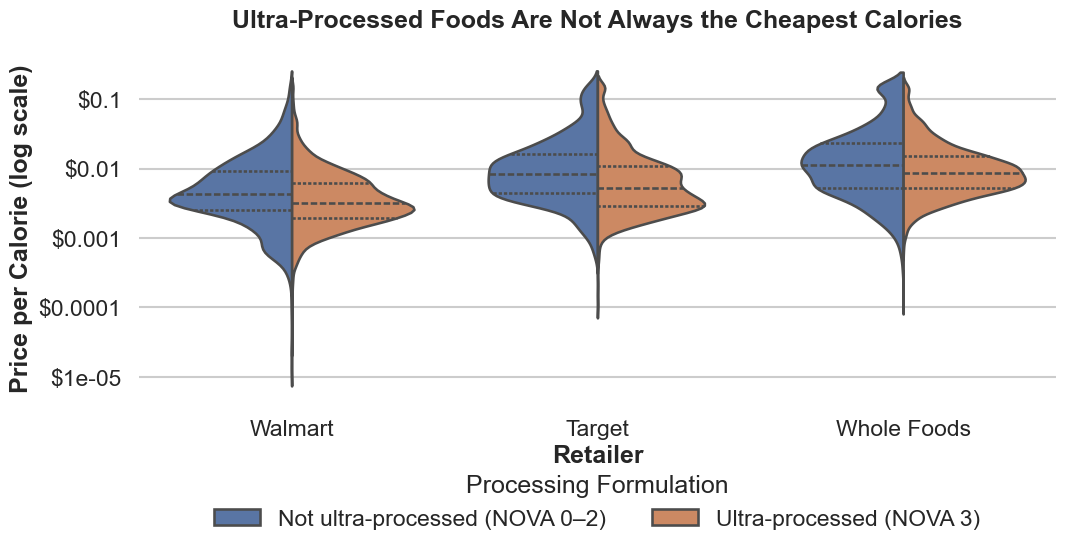

In [16]:
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(
    data=df_plot,
    x="store",
    y="log10_ppc_cap",
    hue="ultra_processed",
    split=True,
    inner="quart",
    order=["Walmart", "Target", "WholeFoods"],
    palette=["#4c72b0", "#dd8452"],
    ax=ax,
)

# Use a FuncFormatter to display log10 prices as readable dollar strings
def log10_dollars(x, pos):
    val = 10 ** x
    return f"${val:g}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(log10_dollars))
ax.set_xlabel("Retailer", fontweight="bold")
ax.set_ylabel("Price per Calorie (log scale)", fontweight="bold")
ax.set_xticklabels(["Walmart", "Target", "Whole Foods"])
ax.set_title("Ultra-Processed Foods Are Not Always the Cheapest Calories", pad=20, fontweight="bold")

handles, labels = ax.get_legend_handles_labels()
# Fix legend overlap by using upper center and adjusting bbox_to_anchor downward
ax.legend(handles, ["Not ultra-processed (NOVA 0–2)", "Ultra-processed (NOVA 3)"], \
          title="Processing Formulation", \
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Remove surrounding spines to increase the data-ink ratio
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


### Checkpoint figure B — Density: processing score vs cost per calorie

**Takeaway angle:** Relationship between **FPro** (continuous processing score) and **affordability**; mass of products in (FPro, log ppc) plane.

**Encodings:** 2D hexbin density, optionally overlaid by store in a second version.

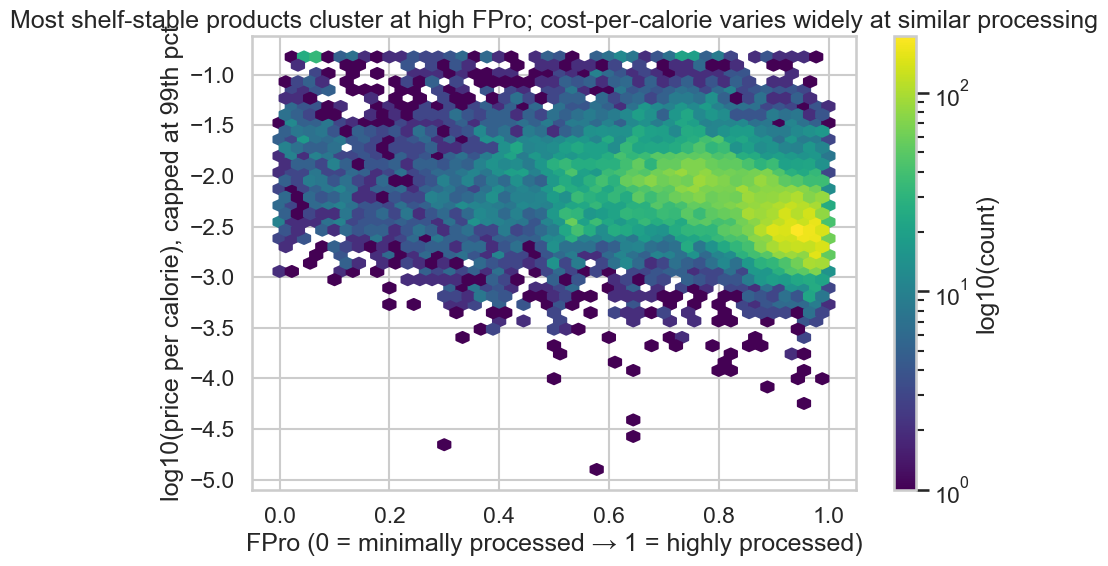

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(
    df_plot["FPro"],
    df_plot["log10_ppc_cap"],
    gridsize=45,
    cmap="viridis",
    mincnt=1,
    bins="log",
)
cb = fig.colorbar(hb, ax=ax, label="log10(count)")
ax.set_xlabel("FPro (0 = minimally processed → 1 = highly processed)")
ax.set_ylabel("log10(price per calorie), capped at 99th pct")
ax.set_title("Most shelf-stable products cluster at high FPro; cost-per-calorie varies widely at similar processing")
plt.tight_layout()
plt.show()

### Checkpoint figure C — As processing rises, does “cheap calories” persist? By store

**Takeaway angle:** Within each retailer, track **median** price per calorie across **FPro quintiles** — tests whether “more processed ⇒ cheaper calories” holds uniformly.

**Encodings:** x = FPro quintile (ordered), y = median log10(ppc), color = store (line plot).

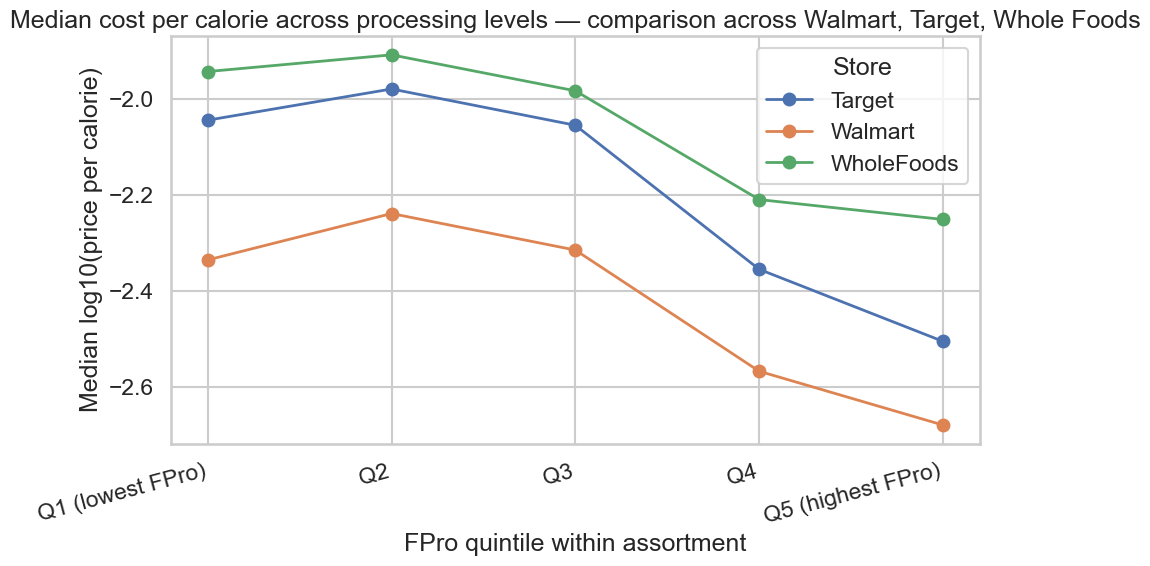

In [18]:
df_line = df_plot.copy()
df_line["fpro_quintile"] = pd.qcut(df_line["FPro"], q=5, labels=["Q1 (lowest FPro)", "Q2", "Q3", "Q4", "Q5 (highest FPro)"], duplicates="drop")
line_df = (
    df_line.groupby(["store", "fpro_quintile"], observed=True)
    .agg(med_log_ppc=("log10_ppc_cap", "median"), n=("name", "count"))
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 6))
for store, sub in line_df.groupby("store"):
    ax.plot(sub["fpro_quintile"].astype(str), sub["med_log_ppc"], marker="o", linewidth=2, label=store)
ax.set_xlabel("FPro quintile within assortment")
ax.set_ylabel("Median log10(price per calorie)")
ax.set_title("Median cost per calorie across processing levels — comparison across Walmart, Target, Whole Foods")
ax.legend(title="Store")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### EDA trends to mention in your checkpoint paragraph

1. **Missing data:** Large gaps in `price` / `price percal` — any affordability claim should state you restricted to products with both (or describe imputation if you choose one later).

2. **Skew:** `price percal` is heavy-tailed; **log transform** (and/or **winsorizing** at high end) is standard for visualization and comparison.

3. **Store mix:** Whole Foods has the most SKUs in this extract; check whether patterns are **composition effects** (different category mixes) vs intrinsic store pricing — stratifying by `category` in a later draft strengthens causality-style claims.

4. **Processing vs nutrients:** Ultra-processed share is high overall (~76% in core subset); **sugar** and **sodium** often move with **FPro** — explore category-level faceting for a nutrition-focused final graphic.

5. **Candidate plots above:**  
   - **A** emphasizes **retailer × ultra-processed** affordability distributions.  
   - **B** shows the **global joint structure** of processing vs cost per calorie.  
   - **C** is strongest for a **clear story about monotonicity** (or lack thereof) of “cheap calories” as processing increases, **per store**.

**Suggested checkpoint preference framing:** Pick the figure whose title can state a **single testable takeaway** (e.g. C if your story is cross-store comparison of the FPro–affordability gradient; A if your story is ultra-processed vs not within store).